# Sentiment Scoring Generation — Probability Weighting & Mean-Centering
### Brazilian Financial News (2016–2025)

This notebook constructs a **final weekly sentiment score** from the fine-tuned FinBERT-PT-BR model output by applying a simple two-step approach:

1. **Probability weighting**: Each article contributes `pos − neg` (probability difference) to the weekly aggregate, using the full softmax probability distribution rather than binary class labels.

2. **Historical mean-centering**: The raw weekly score is shifted by the corpus-wide mean (μ), anchoring the zero line to the historical average rather than to the arbitrary class-balance midpoint. Positive values on the final score indicate **above-average** sentiment weeks; negative values indicate **below-average** weeks.

---

### Table of Contents
1. [Imports & Configuration](#1-imports--configuration)
2. [Data Loading & Preparation](#2-data-loading--preparation)
3. [Scoring: Step-by-step](#3-scoring-step-by-step)
   - 3.1 [Probability Weighting](#31-probability-weighting)
   - 3.2 [Mean-Centering](#32-mean-centering)

4. [Historical Sentiment Index](#4-historical-sentiment-index)
5. [Export](#5-export)

## 1. Imports & Configuration

Standard scientific-Python stack. Two project-specific helpers are defined here and reused throughout:
- `week_key_to_date` — converts ISO week strings (e.g. `"2020-W11"`) to the Monday `Timestamp` of that week.
- `prepare_sentiment_frame` — normalises raw softmax scores to a proper probability triplet `[pos, neg, neu]`, adds `net_score`, and corrects the year field for any records timestamped in 2026.


In [11]:
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

FINETUNED_RESULTS_PATH = Path("output/finetuned_model_classified.jsonl")
COLORS = {"POSITIVE": "#27AE60", "NEGATIVE": "#E74C3C", "NEUTRAL": "#3498DB"}

def week_key_to_date(wk: str) -> pd.Timestamp:
    year, week = wk.split("-W")
    return pd.Timestamp.fromisocalendar(int(year), int(week), 1)

def prepare_sentiment_frame(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    score_sum = frame["score_positive"] + frame["score_negative"] + frame["score_neutral"]
    frame["pos"] = frame["score_positive"] / score_sum
    frame["neg"] = frame["score_negative"] / score_sum
    frame["neu"] = frame["score_neutral"] / score_sum
    frame["confidence"] = frame.apply(
        lambda r: {"POSITIVE": r["pos"], "NEGATIVE": r["neg"], "NEUTRAL": r["neu"]}[r["predicted_label"]], axis=1
    )
    frame["net_score"] = frame["pos"] - frame["neg"]
    frame["year"] = frame["week_key"].str[:4].astype(int)
    frame.loc[frame["year"] == 2026, "year"] = 2025
    return frame


## 2. Data Loading & Preparation

Reads the fine-tuned model's JSONL output, normalises the raw softmax scores into a proper probability triplet `[pos, neg, neu]` (ensuring each row sums to exactly 1.0), and extracts temporal features. Only records from 2016–2025 are kept.

**Why normalise?** The model outputs logits that go through softmax, but floating-point rounding can cause slight deviations from 1.0. Explicit normalisation prevents any drift when computing weighted contributions.


In [12]:
df_raw = pd.read_json(FINETUNED_RESULTS_PATH, lines=True)
df = prepare_sentiment_frame(df_raw)
df["published_at"] = pd.to_datetime(df["published_at"], format="ISO8601", utc=True)
df["week_num"] = df["week_key"].str.extract(r"W(\d+)").astype(int)
df["week_start"] = df["week_key"].map(week_key_to_date)
df = df[df["year"].between(2016, 2025)].copy().reset_index(drop=True)

n_pos = (df["predicted_label"] == "POSITIVE").sum()
n_neg = (df["predicted_label"] == "NEGATIVE").sum()
n_neu = (df["predicted_label"] == "NEUTRAL").sum()
total = len(df)
print(f"Total: {total:,}  |  POSITIVE: {n_pos:,} ({n_pos/total:.1%})  |  "
      f"NEGATIVE: {n_neg:,} ({n_neg/total:.1%})  |  NEUTRAL: {n_neu:,} ({n_neu/total:.1%})")
print(f"Interval: {df['published_at'].min().date()} → {df['published_at'].max().date()}")
df[["predicted_label", "pos", "neg", "neu", "net_score", "week_key"]].head(5)


Total: 56,498  |  POSITIVE: 10,635 (18.8%)  |  NEGATIVE: 23,704 (42.0%)  |  NEUTRAL: 22,159 (39.2%)
Interval: 2016-01-04 → 2025-12-31


,predicted_label,pos,neg,neu,net_score,week_key
0,NEGATIVE,0.050505,0.826026,0.123469,-0.775521,2016-W01
1,NEUTRAL,0.055476,0.200188,0.744336,-0.144712,2016-W01
2,NEGATIVE,0.159091,0.621140,0.219769,-0.462049,2016-W01
3,NEGATIVE,0.028029,0.886956,0.085015,-0.858927,2016-W01
4,NEGATIVE,0.081999,0.491671,0.426330,-0.409672,2016-W01


## 3. Scoring: Step-by-step

A simple two-step strategy produces the final weekly sentiment index:

### 3.1 Probability Weighting

Each article contributes its softmax probability difference to the weekly aggregate:

$$\text{contrib}_i = p_i^+ - p_i^-$$

where $p^+$ and $p^-$ are the normalised softmax probabilities for POSITIVE and NEGATIVE respectively. This applies to **all articles**, regardless of label. The weekly raw score is the arithmetic mean of all per-article contributions.

**Rationale:** Using probability differences rather than binary labels leverages the full learned confidence distribution from the model, capturing both strong and weak signals within each predicted class.

### 3.2 Mean-Centering

The dataset has a structural class imbalance:
- **NEGATIVE**: 42.0%
- **NEUTRAL**: 39.2%
- **POSITIVE**: 18.8%

As a result, the raw weekly average score is chronically negative. We correct this by subtracting the long-run historical mean:

$$\text{final\_score}_w = \overline{\text{contrib}}_w - \mu_{\text{hist}}$$

**Interpretation after mean-centering:**
- `final_score > 0` → above the historical average (optimistic week)
- `final_score = 0` → exactly at the long-run baseline
- `final_score < 0` → below the historical average (pessimistic week)

**Smoothing:** We apply a 13-week centred moving average (approximately 1 quarter) to filter single-week noise while preserving trend reversals.


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 1: Per-article contribution score
# ─────────────────────────────────────────────────────────────────────────────
# Each article contributes: pos - neg
# This uses the full probability distribution, not just the predicted class label.

df["contrib"] = df["pos"] - df["neg"]

# ─────────────────────────────────────────────────────────────────────────────
# Step 2: Weekly aggregation
# ─────────────────────────────────────────────────────────────────────────────
# The weekly score is the arithmetic mean of all per-article contributions.

ws = (
    df.groupby(["week_key", "week_start"])
    .agg(
        n_articles = ("contrib", "count"),
        n_positive = ("predicted_label", lambda x: (x == "POSITIVE").sum()),
        n_negative = ("predicted_label", lambda x: (x == "NEGATIVE").sum()),
        n_neutral  = ("predicted_label", lambda x: (x == "NEUTRAL").sum()),
        raw_score  = ("contrib", "mean"),
    )
    .reset_index()
    .sort_values("week_start")
    .reset_index(drop=True)
)
ws["rate_pos"] = ws["n_positive"] / ws["n_articles"]
ws["rate_neg"] = ws["n_negative"] / ws["n_articles"]
ws["rate_neu"] = ws["n_neutral"]  / ws["n_articles"]

# ─────────────────────────────────────────────────────────────────────────────
# Step 3: Mean-centering to correct class-imbalance baseline
# ─────────────────────────────────────────────────────────────────────────────

mu_hist    = ws["raw_score"].mean()
sigma_hist = ws["raw_score"].std()
ws["final_score"] = ws["raw_score"] - mu_hist

# 13-week centred moving average (~1 quarter)
ws["ma13"] = ws["final_score"].rolling(13, center=True, min_periods=6).mean()

print("=== Raw Score (before centering) ===")
print(f"  Mean  : {mu_hist:+.4f}  ← subtracted as baseline")
print(f"  Std   : {sigma_hist:.4f}")
print(f"  Min   : {ws['raw_score'].min():+.4f}   Max: {ws['raw_score'].max():+.4f}")
print(f"  % weeks > 0 : {(ws['raw_score'] > 0).mean():.1%}\n")

print("=== Final Score (after centering) ===")
print(f"  Mean  : {ws['final_score'].mean():+.6f}  (exactly 0 by construction)")
print(f"  Std   : {ws['final_score'].std():.4f}")
print(f"  Min   : {ws['final_score'].min():+.4f}   Max: {ws['final_score'].max():+.4f}")
print(f"  % weeks > 0 (raw)  : {(ws['final_score'] > 0).mean():.1%}")
print(f"  % weeks > 0 (MA13) : {(ws['ma13'].dropna() > 0).mean():.1%}")
print(f"\n  → μ_hist subtracted: {mu_hist:+.4f}")

dates = ws["week_start"]

=== Raw Score (before centering) ===
  Mean  : -0.1766  ← subtracted as baseline
  Std   : 0.1139
  Min   : -0.6019   Max: +0.1882
  % weeks > 0 : 6.9%

=== Final Score (after centering) ===
  Mean  : +0.000000  (exactly 0 by construction)
  Std   : 0.1139
  Min   : -0.4253   Max: +0.3648
  % weeks > 0 (raw)  : 49.4%
  % weeks > 0 (MA13) : 47.9%

  → μ_hist subtracted: -0.1766


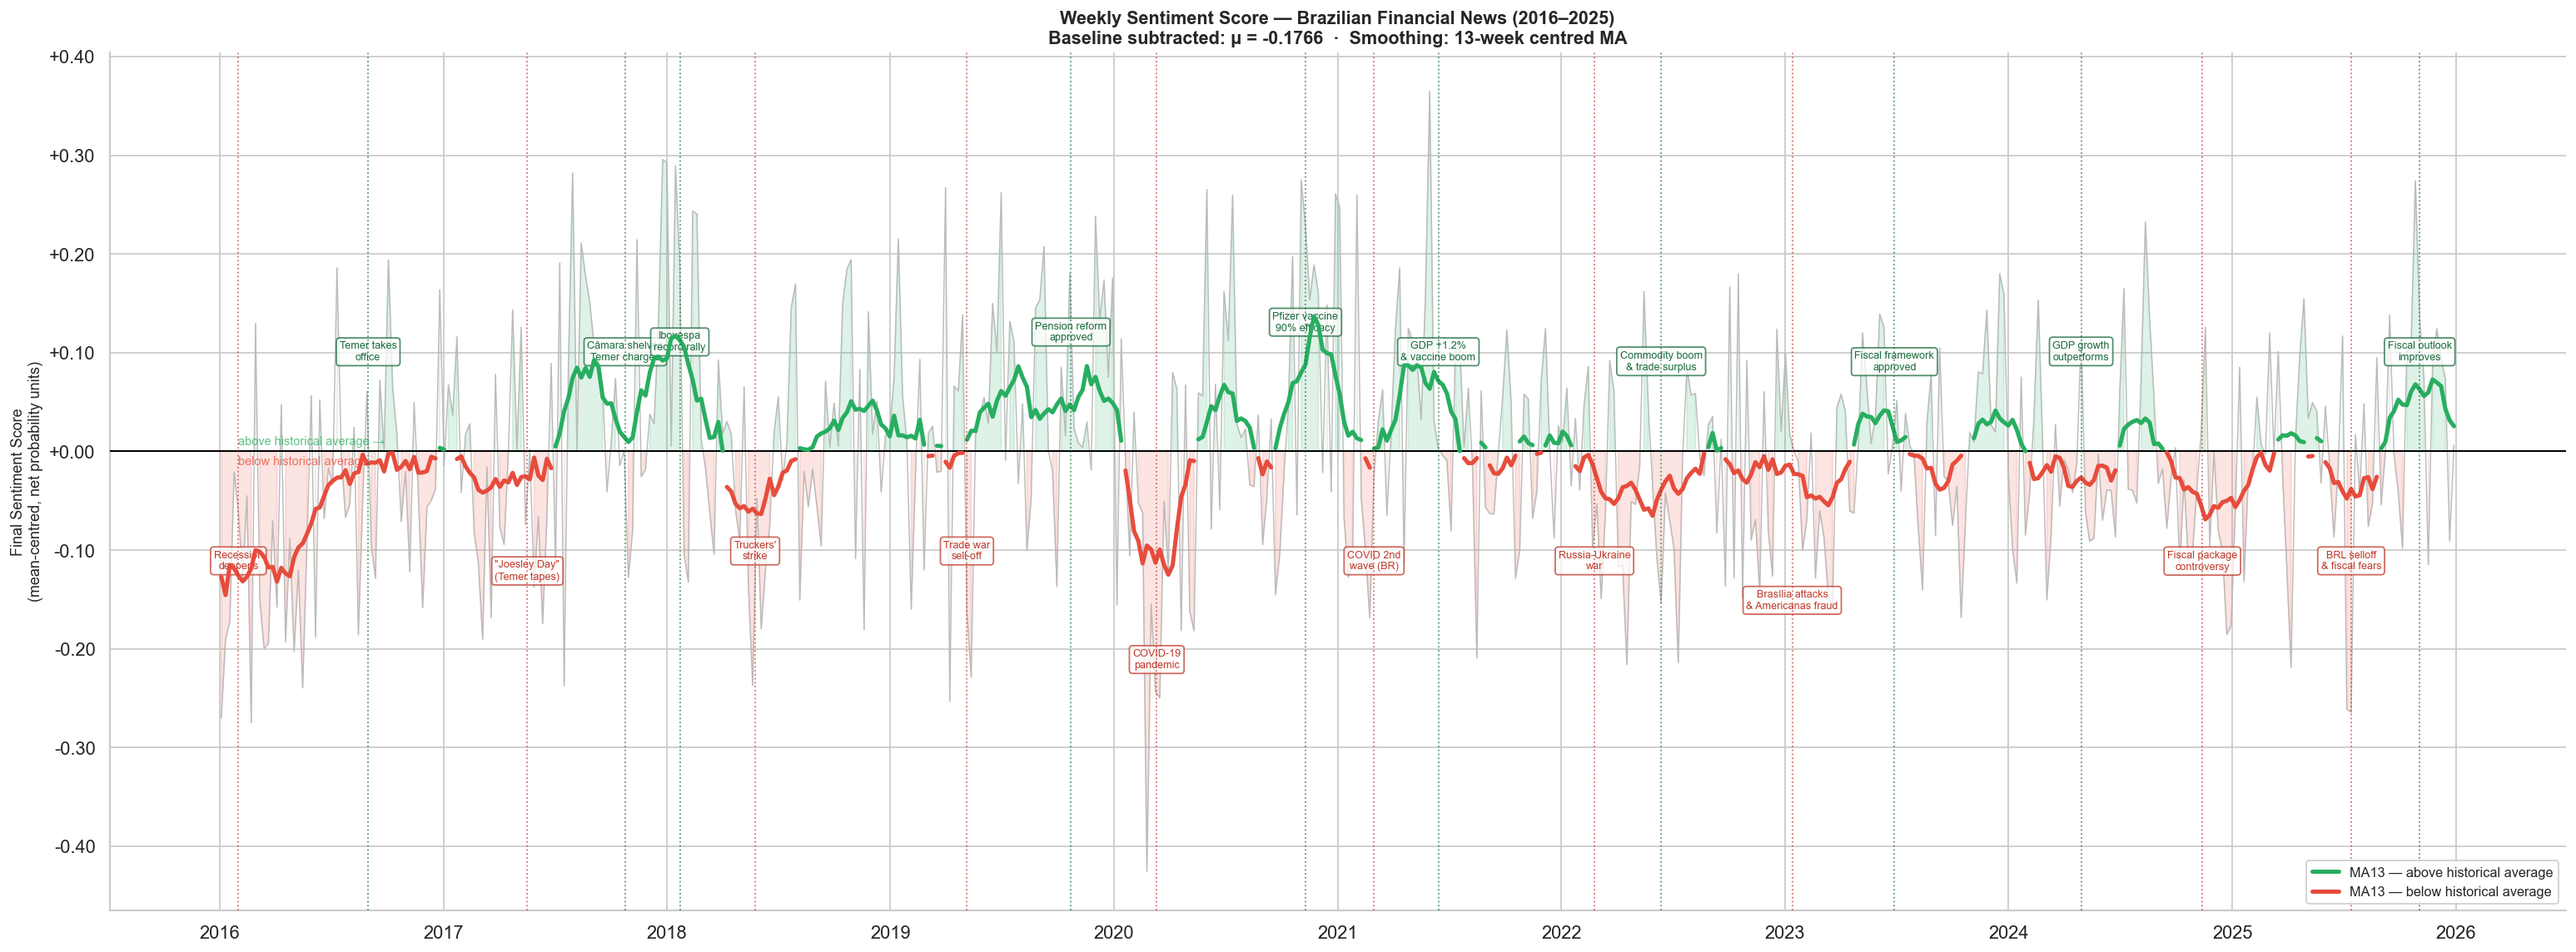

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Historical Weekly Sentiment Score — Full chart (2016–2025)
# ─────────────────────────────────────────────────────────────────────────────
#
# Single panel: weekly score (filled area) + 13-week MA (coloured line)
# The MA line is green when above zero (above-average sentiment) and red
# when below, making trend reversals immediately legible.
#
# EVENTS dict:  (label, y_offset, colour, va)
#   Exactly 2 events per year (2016–2025): one positive peak and one negative
#   trough, anchored to the most significant scoring excursions each year.
#   Colours: dark red (#C0392B) for crises/troughs,
#            dark green (#1A6B3C) for rallies/peaks.

EVENTS = {
    # ── 2016 ─────────────────────────────────────────────────────────────────
    "2016-02-01": ("Recession\ndeepens",                   -0.10, "#C0392B", "top"),
    "2016-08-31": ("Temer takes\noffice",                   0.09, "#1A6B3C", "bottom"),
    # ── 2017 ─────────────────────────────────────────────────────────────────
    "2017-05-18": ('"Joesley Day"\n(Temer tapes)',          -0.11, "#C0392B", "top"),
    "2017-10-25": ("Câmara shelves\nTemer charges",          0.09, "#1A6B3C", "bottom"),
    # ── 2018 ─────────────────────────────────────────────────────────────────
    "2018-01-22": ("Ibovespa\nrecord rally",                 0.10, "#1A6B3C", "bottom"),
    "2018-05-25": ("Truckers'\nstrike",                     -0.09, "#C0392B", "top"),
    # ── 2019 ─────────────────────────────────────────────────────────────────
    "2019-05-06": ("Trade war\nsell-off",                   -0.09, "#C0392B", "top"),
    "2019-10-23": ("Pension reform\napproved",               0.11, "#1A6B3C", "bottom"),
    # ── 2020 ─────────────────────────────────────────────────────────────────
    "2020-03-11": ("COVID-19\npandemic",                    -0.20, "#C0392B", "top"),
    "2020-11-09": ("Pfizer vaccine\n90% efficacy",           0.12, "#1A6B3C", "bottom"),
    # ── 2021 ─────────────────────────────────────────────────────────────────
    "2021-03-01": ("COVID 2nd\nwave (BR)",                  -0.10, "#C0392B", "top"),
    "2021-06-14": ("GDP +1.2%\n& vaccine boom",              0.09, "#1A6B3C", "bottom"),
    # ── 2022 ─────────────────────────────────────────────────────────────────
    "2022-02-24": ("Russia-Ukraine\nwar",                   -0.10, "#C0392B", "top"),
    "2022-06-13": ("Commodity boom\n& trade surplus",        0.08, "#1A6B3C", "bottom"),
    # ── 2023 ─────────────────────────────────────────────────────────────────
    "2023-01-13": ("Brasília attacks\n& Americanas fraud",  -0.14, "#C0392B", "top"),
    "2023-06-29": ("Fiscal framework\napproved",             0.08, "#1A6B3C", "bottom"),
    # ── 2024 ─────────────────────────────────────────────────────────────────
    "2024-04-29": ("GDP growth\noutperforms",                0.09, "#1A6B3C", "bottom"),
    "2024-11-13": ("Fiscal package\ncontroversy",           -0.10, "#C0392B", "top"),
    # ── 2025 ─────────────────────────────────────────────────────────────────
    "2025-07-14": ("BRL selloff\n& fiscal fears",           -0.10, "#C0392B", "top"),
    "2025-11-03": ("Fiscal outlook\nimproves",               0.09, "#1A6B3C", "bottom"),
}

fig, ax = plt.subplots(figsize=(24, 9))

raw = ws["final_score"].values
ma  = ws["ma13"].values

# Filled background areas
ax.fill_between(dates, raw, 0,
                where=(raw >= 0), color=COLORS["POSITIVE"], alpha=0.15, zorder=1)
ax.fill_between(dates, raw, 0,
                where=(raw <  0), color=COLORS["NEGATIVE"], alpha=0.15, zorder=1)

# Weekly raw score — thin grey line
ax.plot(dates, raw, color="#BBBBBB", linewidth=0.8, zorder=2)

# MA13 coloured by sign
pos_ma = np.where(ma >= 0, ma, np.nan)
neg_ma = np.where(ma <  0, ma, np.nan)
ax.plot(dates, pos_ma, color=COLORS["POSITIVE"], linewidth=2.8, zorder=4,
        label="MA13 — above historical average")
ax.plot(dates, neg_ma, color=COLORS["NEGATIVE"], linewidth=2.8, zorder=4,
        label="MA13 — below historical average")

ax.axhline(0, color="black", linewidth=1.1, zorder=3)

# ── Event annotations ─────────────────────────────────────────────────────
for date_str, (label, y_off, ec, va) in EVENTS.items():
    ev_date = pd.Timestamp(date_str)
    ax.axvline(ev_date, color=ec, linewidth=1.0, linestyle=":", alpha=0.70, zorder=5)
    ax.text(ev_date, y_off, label,
            fontsize=7, color=ec, ha="center",
            va="bottom" if va == "bottom" else "top",
            bbox=dict(fc="white", ec=ec, alpha=0.75, pad=1.5,
                      boxstyle="round,pad=0.3"))

# Year grid lines
for year in range(2016, 2026):
    ax.axvline(pd.Timestamp(f"{year}-01-01"), color="lightgray",
               linewidth=0.5, alpha=0.5, zorder=0)

# Zero-line labels
ax.text(dates.iloc[4],  0.004, "above historical average →",
        fontsize=8, color=COLORS["POSITIVE"], va="bottom", alpha=0.75)
ax.text(dates.iloc[4], -0.004, "below historical average →",
        fontsize=8, color=COLORS["NEGATIVE"], va="top", alpha=0.75)

ax.set_ylabel("Final Sentiment Score\n(mean-centred, net probability units)", fontsize=10)
ax.set_title(
    "Weekly Sentiment Score — Brazilian Financial News (2016–2025)\n"
    f"Baseline subtracted: μ = {mu_hist:+.4f}  ·  Smoothing: 13-week centred MA",
    fontsize=12, fontweight="bold"
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.2f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)

plt.tight_layout()


## 4. Export

The complete weekly sentiment index is saved to `output/weekly_sentiment_scores.csv`, with one row per week containing both intermediate and final metrics.

### Output columns

| Column | Description |
|--------|-------------|
| `week_key` | ISO week identifier (e.g. `2020-W11`) |
| `week_start` | Monday of the week (date) |
| `n_articles` | Number of articles classified that week |
| `n_positive`, `n_negative`, `n_neutral` | Article counts by predicted class |
| `rate_pos`, `rate_neg`, `rate_neu` | Class rates (sum = 1.0) |
| `raw_score` | Mean of per-article contributions (before centering) |
| `final_score` | Centered score: `raw_score − μ_hist` |

| `ma13` | 13-week centred moving average of final_score |

In [15]:
OUTPUT_CSV = Path("output/weekly_sentiment_scores.csv")

export_cols = [
    "week_key",
    "week_start",
    "n_articles",
    "n_positive",
    "n_negative",
    "n_neutral",
    "rate_pos",
    "rate_neg",
    "rate_neu",
    "raw_score",
    "final_score",
    "ma13",
]

ws[export_cols].to_csv(OUTPUT_CSV, index=False, float_format="%.6f")
print(f"Saved {len(ws)} weeks → {OUTPUT_CSV}")

Saved 522 weeks → output\weekly_sentiment_scores.csv
